# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Daffa Aufa Afif| 5054251022|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [240]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd # Menyipan datanya nanti
import numpy as np # kalkulasi math
import matplotlib.pyplot as plt # visualisasi
import seaborn as sns # visualisasi2
import os
import shutil
import kagglehub
from google.colab import files
from dotenv import load_dotenv
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_curve, roc_auc_score


This dataset consists of multiple independent variables and one dependent variable (Outcome). Independent variables include:

    Pregnancies: Number of times pregnant
    Glucose: Plasma Glucose Concentration a 2-hour in an Oral Glucose Tolerance Test (mg/dl).
    BloodPressure: Diastolic Blood Pressure (mm/Hg).
    SkinThickness: Triceps Skin Fold Thickness (mm)
    Insulin: 2-Hour Serum Insulin (mu U/ml)
    BMI: Body Mass Index (weight in kg/(height in m)^2)
    DiabetesPedigreeFunction: It provides information about diabetes history in relatives and genetic relationship of those relatives with patients. Higher Pedigree Function means patient is more likely to have diabetes.
    Age: Age of an individual (years)
    Outcome: Target Variable (0 or 1) where ‘0’ denotes patient is not diabetic and ‘1’ denotes patient is diabetic.


In [241]:
# 1. Download the dataset
path = kagglehub.dataset_download('jamaltariqcheema/pima-indians-diabetes-dataset')

# 2. Create the destination folder if it doesn't exist
os.makedirs('/data', exist_ok=True)

# 3. Move or copy files to /data
# kagglehub downloads a directory, so we copy its contents into /data
for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join('/data', item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Dataset moved to /data successfully!")


Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Dataset moved to /data successfully!


In [242]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('/data/diabetes.csv')
print(df.head(),end="\n\n")
print(df.info(),end="\n\n")
print(df.describe(),end="\n\n")
print(df.isnull().sum())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   76

Axes(0.125,0.11;0.775x0.77)
Non-Diabet: 268 	Diabet: 500
Selisih:  232 (30.21%)


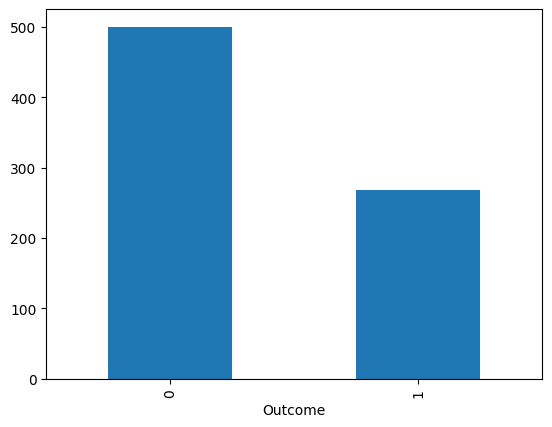

In [243]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df['Outcome'].value_counts().plot(kind='bar'))
_neg = df['Outcome'].value_counts()[0]
_pos = df['Outcome'].value_counts()[1]
print("Non-Diabet:",_pos,"\tDiabet:",_neg)
print("Selisih: ",_neg-_pos, f"({round(abs(_neg-_pos)/(_neg+_pos)*100,2)}%)")

Terlihat bahwa data imbalance

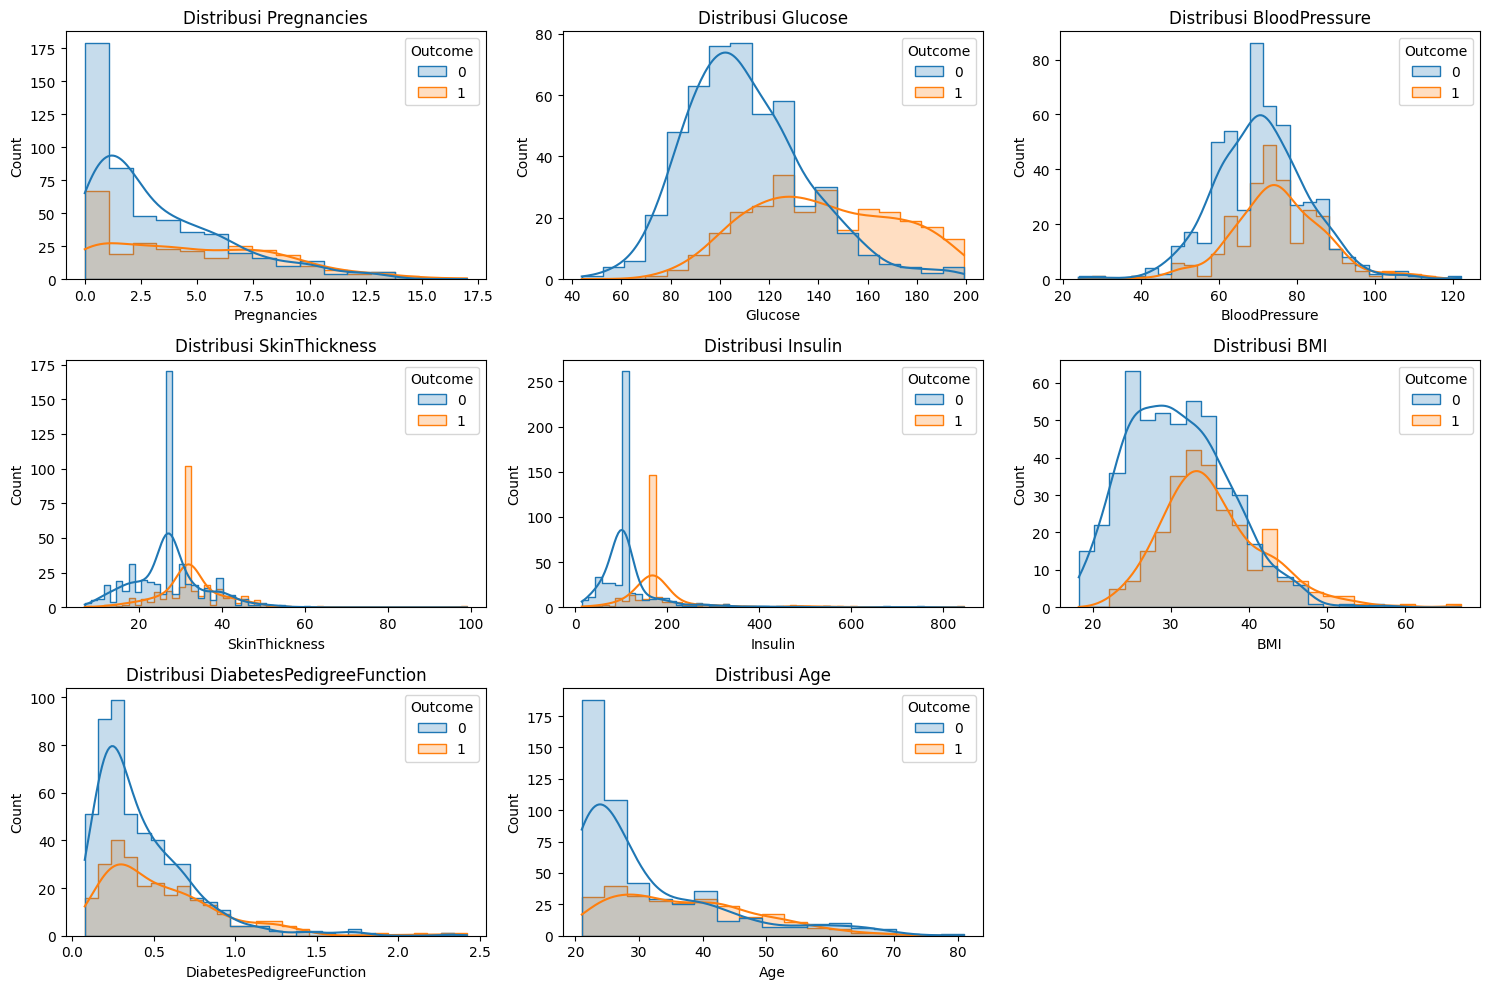

In [244]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
_features = [col for col in df.columns if col.lower() != 'outcome']
plt.figure(figsize=(15, 10))
for i, col in enumerate(_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, element='step')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

Dari Histogram KDE, beberapa fitur memiliki pembeda signifikan antara `Outcome` $0$ dan $1$ yaitu: Glucose, SkinThickness, Insulin, dan BMI. Fitur lainnya terlihat overlap satu dengan lainnya

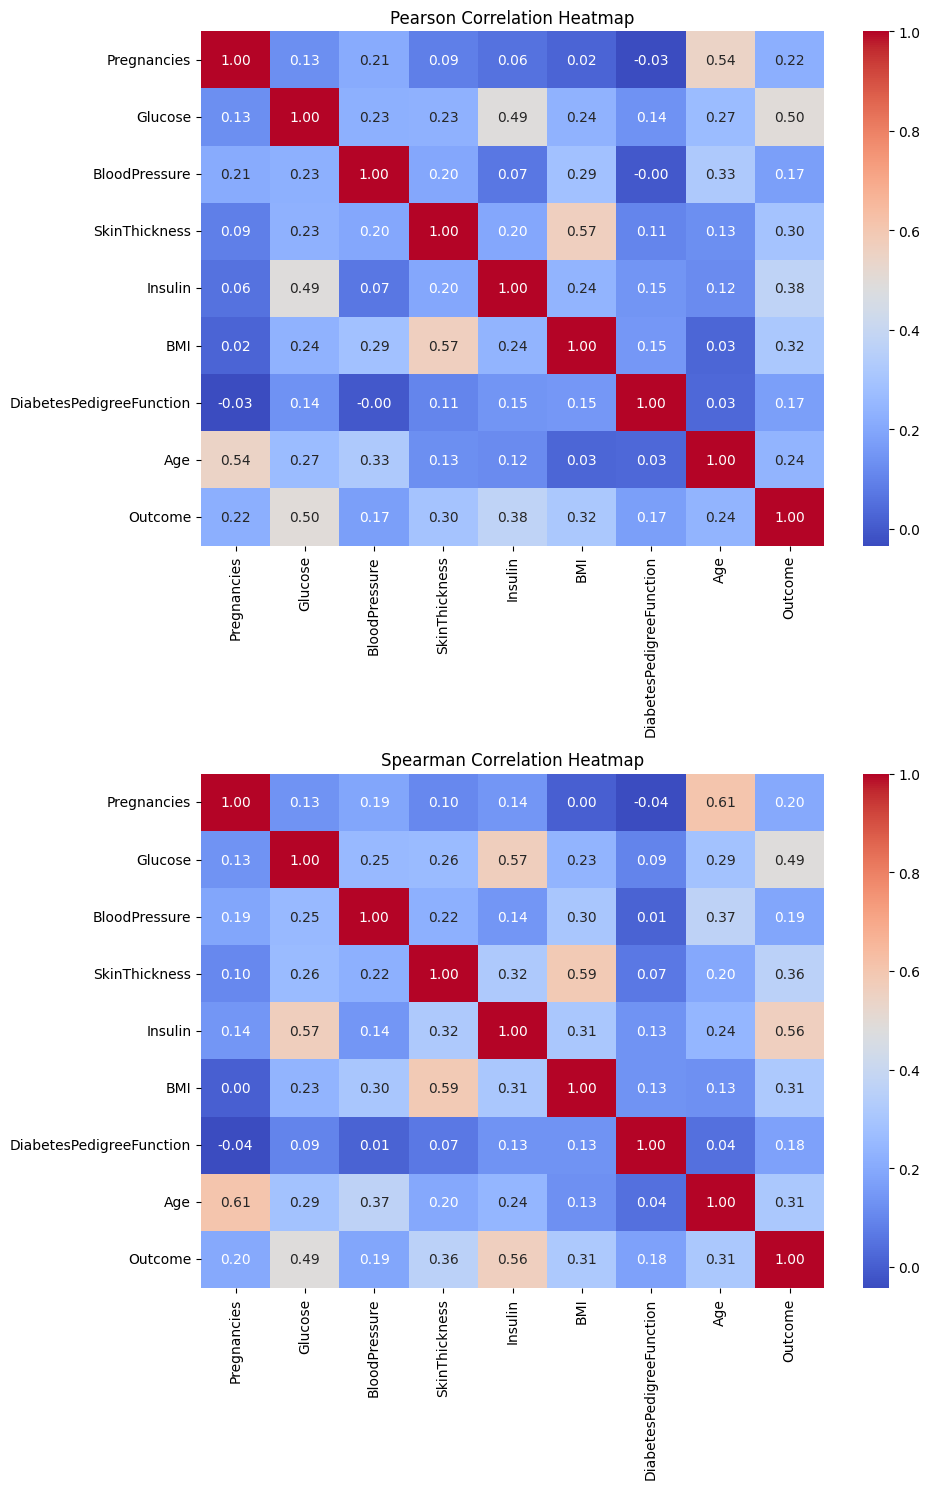

In [245]:
# Tampilkan heatmap korelasi antar fitur.

corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')
fig, axes = plt.subplots(2, 1, figsize=(10, 15))

# Heatmap Pearson (axes atas)
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Pearson Correlation Heatmap')

# Heatmap Spearman (axes bawah)
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Spearman Correlation Heatmap')

plt.tight_layout()
plt.show()

Dari kedua heatmap terlihat bahwa fitur paling berpengaruh adalah Glucose, Insulin, SkinThickness, BMI, dan Age. Sesuai dengan hasil observasi sebelumnya.

Penggunaan dua tipe korelasi berbeda hanyalah untuk melihat sejauh apa perbedaannya. Dapat disimpulkan bahwa Spearman lebih cocok karena banyak data yang mengalami skewness.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [246]:
#focus = ['Glucose', 'Insulin', 'SkinThickness', 'BMI']
focus = ['Glucose', 'Insulin', 'SkinThickness', 'BMI','Age']


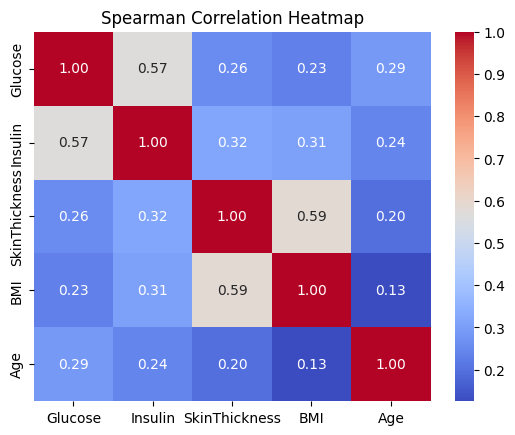

In [247]:
_foc = df[focus]
corr_spearman2 = _foc.corr(method='spearman')
fig= plt.plot(figsize=(20, 15))
sns.heatmap(corr_spearman2, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spearman Correlation Heatmap')
plt.show()

Ada beberapa keterkaitan, tetapi tidak terlalu tinggi

In [248]:
print(df.duplicated().sum())
print(df.isna().sum())

0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


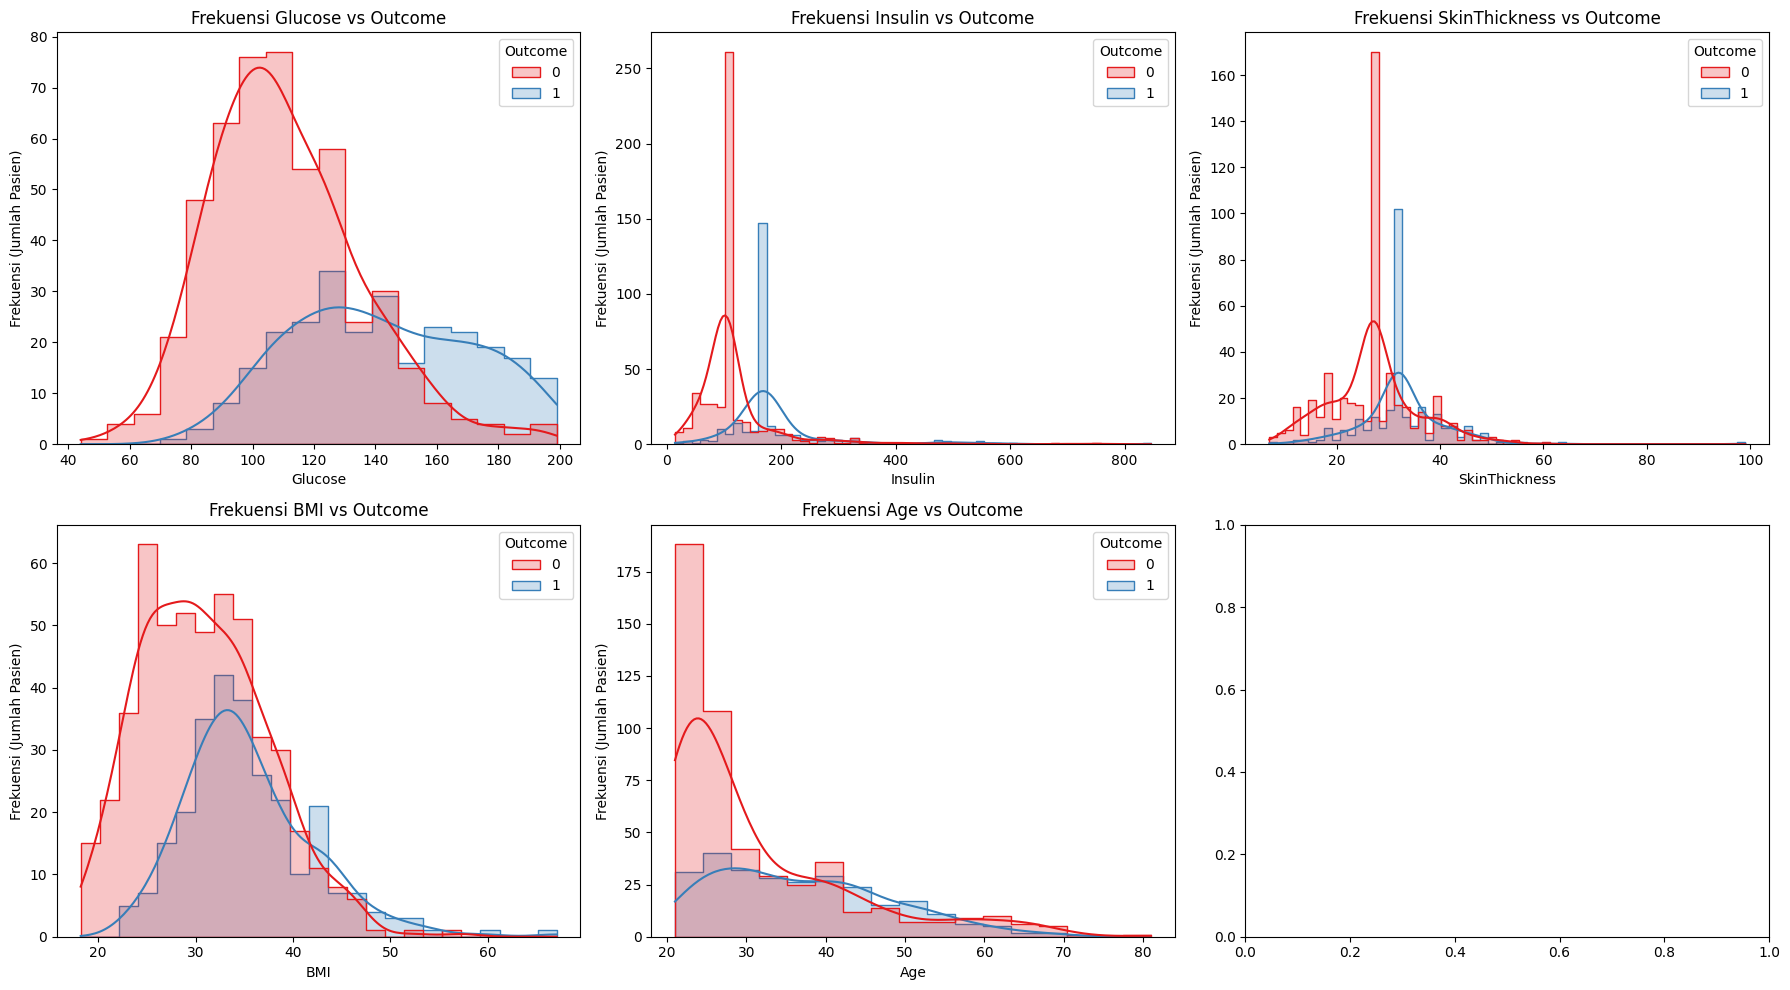

In [249]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(focus):
    sns.histplot(
        data=df,
        x=col,
        hue='Outcome',
        kde=True,
        element='step',
        palette='Set1',
        ax=axes[i]
    )
    axes[i].set_title(f'Frekuensi {col} vs Outcome')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi (Jumlah Pasien)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3177/2315164477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3177/2315164477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3177/2315164477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3177/2315164477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3177/2315164477.py:5: FutureWarning: 

Passin

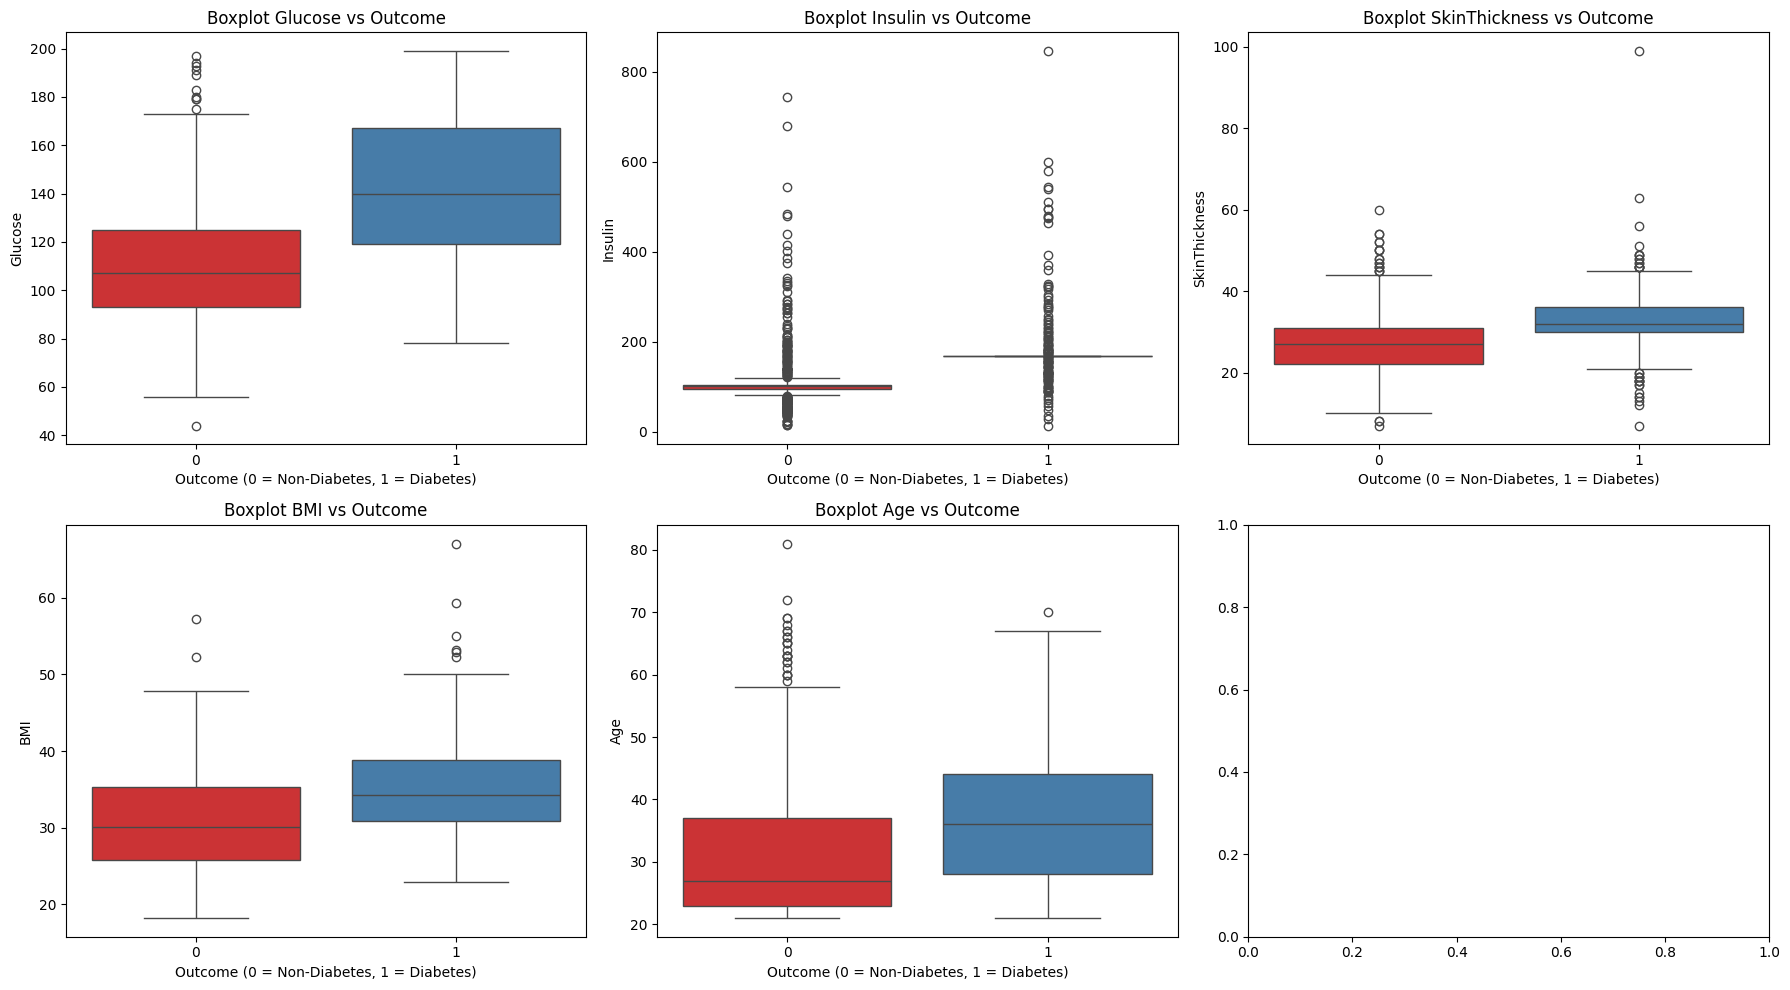

In [250]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(focus):
    sns.boxplot(
        data=df,
        x='Outcome',
        y=col,
        palette='Set1',
        ax=axes[i]
    )
    axes[i].set_title(f'Boxplot {col} vs Outcome')
    axes[i].set_xlabel('Outcome (0 = Non-Diabetes, 1 = Diabetes)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Data bersih, tapi banyak outlier

# 2. Preprocessing

In [251]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
print(df.min(),end="\n\n")
print((df==0).sum())

Pregnancies                  0.000
Glucose                     44.000
BloodPressure               24.000
SkinThickness                7.000
Insulin                     14.000
BMI                         18.200
DiabetesPedigreeFunction     0.078
Age                         21.000
Outcome                      0.000
dtype: float64

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [252]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

Data sudah bersih dari awal

In [253]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df[focus]
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
outlie = True

In [254]:
# Pembersihan Outlier, sebelumnya sudah mencoba dengan oulier, hasilnya buruk
outlie = False
for col in X_train.columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)

In [255]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Ubah lagi jadi pandas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=focus, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=focus, index=X_test.index)

In [256]:
print(X_train.describe().round(2),end="\n\n")
print(X_train_scaled.describe().round(2),end="\n\n")
print(X_test_scaled.describe().round(2))

       Glucose  Insulin  SkinThickness     BMI     Age
count   614.00   614.00         614.00  614.00  614.00
mean    121.71   131.64          28.80   32.36   33.32
std      30.03    57.09           7.61    6.61   11.68
min      56.00    15.00          14.50   18.20   21.00
25%      99.00   102.50          25.00   27.62   24.00
50%     117.00   102.50          28.00   32.40   29.00
75%     140.00   169.50          32.00   36.50   41.00
max     199.00   270.00          42.50   49.81   66.50

       Glucose  Insulin  SkinThickness     BMI     Age
count   614.00   614.00         614.00  614.00  614.00
mean     -0.00    -0.00          -0.00    0.00    0.00
std       1.00     1.00           1.00    1.00    1.00
min      -2.19    -2.04          -1.88   -2.14   -1.06
25%      -0.76    -0.51          -0.50   -0.72   -0.80
50%      -0.16    -0.51          -0.10    0.01   -0.37
75%       0.61     0.66           0.42    0.63    0.66
max       2.58     2.43           1.80    2.64    2.84

       G

# 3. Eksperimen Model

In [257]:
res={}

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [258]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gauss = GaussianNB()
gauss.fit(X_train_scaled, y_train)

GaussianNB()

In [259]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gauss = gauss.predict(X_test_scaled)
y_pred_proba_gauss = gauss.predict_proba(X_test_scaled)[:, 1]
res['GaussianNB'] = {
    'y_pred': y_pred_gauss,
    'y_proba': y_pred_proba_gauss
}
#res

## 3.2 Logistic Regression

In [260]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [261]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
res['LogisticRegression'] = {
    'y_pred': y_pred_logreg,
    'y_proba': y_pred_proba_logreg
}


# 4. Evaluasi Model

In [262]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
metrics_summary = []

for model_name, preds in res.items():
    acc = accuracy_score(y_test, preds['y_pred'])
    prec = precision_score(y_test, preds['y_pred'])
    rec = recall_score(y_test, preds['y_pred'])
    f1 = f1_score(y_test, preds['y_pred'])

    metrics_summary.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })
print(focus)
print("Dengan Outlier?", outlie)
df_metrics = pd.DataFrame(metrics_summary)
print(df_metrics)


['Glucose', 'Insulin', 'SkinThickness', 'BMI', 'Age']
Dengan Outlier? False
                Model  Accuracy  Precision  Recall  F1-Score
0          GaussianNB    0.7662     0.6452  0.7407    0.6897
1  LogisticRegression    0.7403     0.6400  0.5926    0.6154


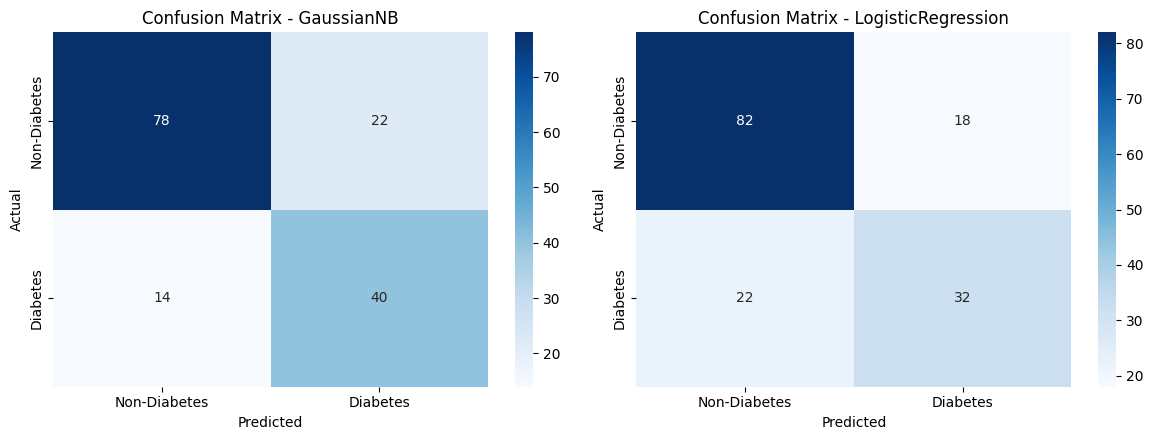

In [263]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (model_name, preds) in enumerate(res.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Diabetes', 'Diabetes'],
                yticklabels=['Non-Diabetes', 'Diabetes'])
    axes[i].set_title(f'Confusion Matrix - {model_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


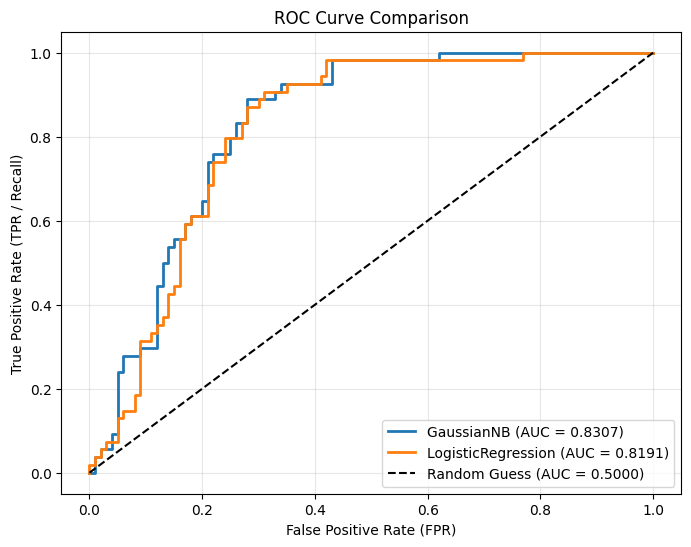

In [264]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(8, 6))

for model_name, preds in res.items():
    fpr, tpr, _ = roc_curve(y_test, preds['y_proba'])
    auc_score = roc_auc_score(y_test, preds['y_proba'])
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', linewidth=2)

# Garis acak (Random Classifier / Baseline)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_3177/2014339560.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


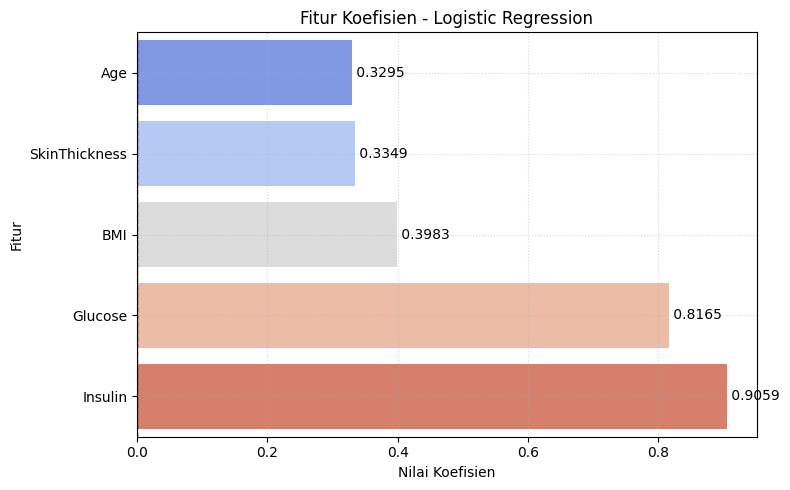

In [265]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
importance = pd.DataFrame({
    'Fitur': focus,
    'Koefisien': logreg.coef_[0]
}).sort_values(by='Koefisien', ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance,
    x='Koefisien',
    y='Fitur',
    palette='coolwarm'
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
for index, value in enumerate(importance['Koefisien']):
    plt.text(value, index, f' {value:.4f}', va='center',fontsize=10)

plt.title('Fitur Koefisien - Logistic Regression')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Eksperimen menunjukkan bahwa Gaussian Naive Bayes menghasilkan nilai Recall yang lebih tinggi ($0.74$) dibandingkan Logistic Regression ($0.59$). Dalam konteks diagnosis medis, Recall merupakan metrik paling krusial karena meminimalkan risiko False Negative (pasien diabetes yang tidak terdeteksi).

Perbedaan performa ini disebabkan oleh karakteristik batas keputusan (decision boundary) kedua model. Logistic Regression memisahkan data menggunakan hyperplane linear (garis lurus), sehingga kesulitan memisahkan kelas pada fitur yang memiliki tingkat tumpang tindih (overlapping) dan skewness yang tinggi seperti yang terlihat pada EDA. Di sisi lain, Gaussian Naive Bayes mengestimasi rata-rata dan varians untuk tiap kelas secara terpisah, menghasilkan batas keputusan kuadratik (melengkung) yang lebih fleksibel dalam menangkap sebaran data non-linear.

Selain pemilihan model, penambahan fitur dan penanganan outlier terbukti meningkatkan performa secara signifikan. Penambahan fitur `Age` pada set kedua memberikan variabel pembeda yang kuat karena distribusi usia pasien diabetes dan non-diabetes memiliki perbedaan rata-rata yang signifikan. Tanpa pembersihan outlier, estimasi rata-rata dan varians pada Gaussian NB menjadi bias, sementara pada Logistic Regression, bobot koefisien fitur tertarik oleh outlier. Hal ini membuktikan bahwa kombinasi pemilihan fitur yang kaya, preprocessing yang tepat, dan pemilihan model non-linear sangat menentukan hasil klasifikasi pada dataset ini.

Hasil percobaan lain tanpa menggunakan `Age` dan pembersihan outlier:

![Tabel metrik evaluasi](/util/table1.png)


![confussion matrix](/util/confus1.png)


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Dari eksperimen ini, disimpulkan bahwa:

    * Logistic Regression yang berbasis *hyperplane linear* kurang optimal memisahkan kelas pada dataset yang memiliki *skewness* dan *overlapping* tinggi, sementara Gaussian NB lebih fleksibel karena memanfaatkan sebaran probabilitas kuadratik.
    * Fitur seperti `Age` mungkin tampak memiliki korelasi yang tidak dominan pada analisis awal, namun memberikan daya pembeda kondisional yang sangat kuat saat dikombinasikan dengan fitur lain.
    * Baik Logistic Regression maupun Gaussian NB terbukti sensitif terhadap outlier, di mana outlier merusak estimasi mean/varians pada Naive Bayes dan menggeser kemiringan bobot (*hyperplane*) pada Logistic Regression.

Adapun saran untuk eksperimen dengan kasus serupa adalah:

    * Penggunaan feature engineering pada fitur fitur berkorelasi rendah
    * Penggunaan metode pembersihan outlier lainnya

